Laboratorio 2 - Deep Learning. Modelos LSTM para las series de tiempo del Laboratorio 1 (ingreso de viajeros internacionales a Guatemala). Se reutilizan train.csv y test.csv generados en el Laboratorio 1 (split cronológico 70/30 por mes, corte en 2021-04) y dos de las series construidas en ese laboratorio: Total y Aérea.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['figure.figsize'] = (10, 4)

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

## 1. Series reutilizadas del Laboratorio 1

Mismo train.csv/test.csv y misma construcción de series por fecha y por Vía que en 02_modelo_arima.ipynb del Laboratorio 1, para que el split temporal sea idéntico al usado con ARIMA/Prophet/Holt-Winters.

In [2]:
train = pd.read_csv('train.csv', encoding='utf-8-sig')
test  = pd.read_csv('test.csv',  encoding='utf-8-sig')

for d in (train, test):
    d['fecha'] = pd.to_datetime(d['Año'].astype(str) + '-' + d['Mes cod'].astype(str) + '-01')

def build(df):
    total = df.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS')
    total.name = 'Total'
    via = df.groupby(['fecha', 'Vía'])['Viajero'].sum().unstack(fill_value=0).sort_index().asfreq('MS')
    return total, via

tot_tr, via_tr = build(train)
tot_te, via_te = build(test)

series_train = {'Total': tot_tr, 'Aérea': via_tr['Aérea']}
series_test  = {'Total': tot_te, 'Aérea': via_te['Aérea']}

for nombre in series_train:
    s_tr, s_te = series_train[nombre], series_test[nombre]
    print(f"{nombre:6s} -> train: {s_tr.index.min().date()} a {s_tr.index.max().date()} (n={len(s_tr)})"
          f" | test: {s_te.index.min().date()} a {s_te.index.max().date()} (n={len(s_te)})")

Total  -> train: 2009-01-01 a 2021-03-01 (n=147) | test: 2021-04-01 a 2026-06-01 (n=63)
Aérea  -> train: 2009-01-01 a 2021-03-01 (n=147) | test: 2021-04-01 a 2026-06-01 (n=63)


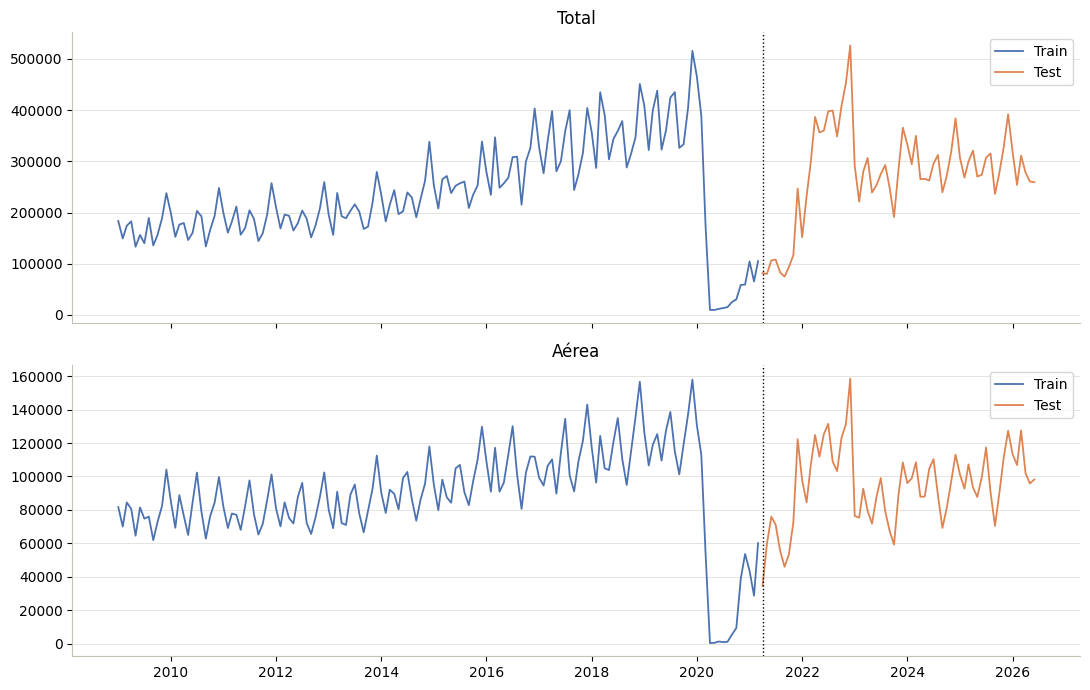

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, nombre in zip(axes, series_train):
    s_tr, s_te = series_train[nombre], series_test[nombre]
    ax.plot(s_tr.index, s_tr.values, color=COLORS[0], linewidth=1.3, label='Train')
    ax.plot(s_te.index, s_te.values, color=COLORS[1], linewidth=1.3, label='Test')
    ax.axvline(s_te.index.min(), color='black', linestyle=':', linewidth=1)
    ax.set_title(nombre)
    ax.legend()
fig.tight_layout()

In [4]:
# chequeo rápido: los valores deben coincidir con los de 02_modelo_arima.ipynb del Laboratorio 1
print('Total  train primeros 3 meses:', series_train['Total'].head(3).round(1).tolist())
print('Aérea  train primeros 3 meses:', series_train['Aérea'].head(3).round(1).tolist())
print('Total  test  últimos 3 meses:', series_test['Total'].tail(3).round(1).tolist())
print('Aérea  test  últimos 3 meses:', series_test['Aérea'].tail(3).round(1).tolist())

Total  train primeros 3 meses: [183505.6, 149426.3, 174237.2]
Aérea  train primeros 3 meses: [81693.0, 70099.0, 84494.0]
Total  test  últimos 3 meses: [278199.0, 260666.0, 259391.0]
Aérea  test  últimos 3 meses: [102029.0, 95804.0, 98211.0]


Las dos series (Total y Aérea) quedan con el mismo train/test del Laboratorio 1: 147 meses de entrenamiento (2009-01 a 2021-03) y 63 meses de prueba (2021-04 en adelante). Con esto ya se puede pasar a construir y tunear los modelos LSTM sobre series_train/series_test.

## 2. Funciones auxiliares para los modelos LSTM

Cada serie se transforma en logaritmo (misma justificación de varianza que en el Laboratorio 1) y se escala a [0, 1] con MinMaxScaler ajustado solo con train (para no filtrar información de test). El pronóstico sobre el horizonte de prueba es recursivo: se predice un mes, se agrega a la ventana de entrada, y se vuelve a predecir el siguiente, hasta cubrir los meses de test.

Para el tuneo de hiperparámetros no se toca test: se separan los últimos 18 meses de train como validación interna y se evalúa el pronóstico recursivo sobre esos 18 meses. Solo al final, con los hiperparámetros ya elegidos, se reentrena con todo train y se pronostica sobre test.

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow', tf.__version__, '| Keras', keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


In [6]:
VAL_MONTHS = 18


def prepare_series(s_train, usa_log1p=False):
    tf_fun, itf_fun = (np.log1p, np.expm1) if usa_log1p else (np.log, np.exp)
    train_t = tf_fun(s_train.values.astype(float))
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_t.reshape(-1, 1)).flatten()
    return dict(transform=tf_fun, inv_transform=itf_fun, scaler=scaler, train_scaled=train_scaled)


def inv_scale(values_scaled, info):
    real_t = info['scaler'].inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).flatten()
    return info['inv_transform'](real_t)


def make_windows(values, look_back):
    X, y = [], []
    for i in range(len(values) - look_back):
        X.append(values[i:i + look_back])
        y.append(values[i + look_back])
    return np.array(X), np.array(y)


def forecast_recursive(model, history_scaled, look_back, steps, clip=(0.0, 1.0)):
    """Pronóstico recursivo mes a mes. Cada predicción escalada se acota a `clip`
    (el rango [0, 1] que el MinMaxScaler ya vio en train) para evitar que un
    pequeño error se amplifique exponencialmente al deshacer la transformación
    logarítmica en un horizonte largo (63 meses). Los valores reales de test
    quedan apenas ~1-2% por encima del máximo de train en ambas series, así que
    este límite no le quita rango útil al pronóstico."""
    window = list(history_scaled[-look_back:])
    preds = []
    for _ in range(steps):
        x = np.array(window[-look_back:]).reshape(1, look_back, 1)
        yhat = float(model.predict(x, verbose=0)[0, 0])
        yhat = float(np.clip(yhat, clip[0], clip[1]))
        preds.append(yhat)
        window.append(yhat)
    return np.array(preds)


def evaluar(real, pred):
    return dict(MAE=mean_absolute_error(real, pred), RMSE=float(np.sqrt(mean_squared_error(real, pred))))


def grid_search(info, build_fn, grid, val_months=VAL_MONTHS, epochs=150, patience=12):
    scaled = info['train_scaled']
    fit_part = scaled[:-val_months]
    val_real = inv_scale(scaled[-val_months:], info)

    filas = []
    for params in grid:
        look_back = int(params['look_back'])
        Xw, yw = make_windows(fit_part, look_back)
        Xw = Xw.reshape(Xw.shape[0], Xw.shape[1], 1)

        keras.utils.set_random_seed(SEED)
        model = build_fn(look_back, params)
        es = keras.callbacks.EarlyStopping(monitor='loss', patience=patience, restore_best_weights=True)
        model.fit(Xw, yw, epochs=epochs, batch_size=int(params.get('batch_size', 8)), verbose=0, callbacks=[es])

        pred_scaled = forecast_recursive(model, fit_part, look_back, val_months)
        pred_real = inv_scale(pred_scaled, info)

        filas.append({**params, **evaluar(val_real, pred_real)})
    return pd.DataFrame(filas).sort_values('RMSE').reset_index(drop=True)


def entrenar_final(info, build_fn, best_params, steps, epochs=300, patience=20):
    scaled = info['train_scaled']
    look_back = int(best_params['look_back'])
    Xw, yw = make_windows(scaled, look_back)
    Xw = Xw.reshape(Xw.shape[0], Xw.shape[1], 1)

    keras.utils.set_random_seed(SEED)
    model = build_fn(look_back, best_params)
    es = keras.callbacks.EarlyStopping(monitor='loss', patience=patience, restore_best_weights=True)
    model.fit(Xw, yw, epochs=epochs, batch_size=int(best_params.get('batch_size', 8)), verbose=0, callbacks=[es])

    pred_scaled = forecast_recursive(model, scaled, look_back, steps)
    pred_real = inv_scale(pred_scaled, info)
    return model, pred_real

## 3. Dos arquitecturas LSTM con tuneo de parámetros

- Modelo A: LSTM de una sola capa + capa densa de salida. Tuneo sobre look_back (tamaño de la ventana de entrada, en meses) y units (neuronas LSTM).
- Modelo B: LSTM apilado de dos capas con Dropout entre capas. Tuneo sobre look_back, units y dropout.

Ambos se entrenan con Adam y EarlyStopping sobre la pérdida de entrenamiento. La selección de hiperparámetros la hace grid_search comparando el pronóstico recursivo sobre los 18 meses de validación reservados dentro de train.

In [7]:
def build_model_A(look_back, params):
    units = int(params['units'])
    model = keras.Sequential([
        keras.Input(shape=(look_back, 1)),
        layers.LSTM(units, activation='tanh'),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=params.get('lr', 0.01)), loss='mse')
    return model


def build_model_B(look_back, params):
    units = int(params['units'])
    dropout = float(params['dropout'])
    model = keras.Sequential([
        keras.Input(shape=(look_back, 1)),
        layers.LSTM(units, activation='tanh', return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(max(units // 2, 8), activation='tanh'),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=params.get('lr', 0.005)), loss='mse')
    return model


grid_A = [dict(look_back=lb, units=u) for lb in [6, 12] for u in [32, 64]]
grid_B = [dict(look_back=lb, units=u, dropout=d) for lb in [6, 12] for u in [64, 128] for d in [0.1, 0.3]]

print(f'Modelo A: {len(grid_A)} combinaciones')
print(f'Modelo B: {len(grid_B)} combinaciones')

Modelo A: 4 combinaciones
Modelo B: 8 combinaciones


## 4. Serie: Total

### 4.1 Tuneo del Modelo A (LSTM simple)

In [8]:
info_total = prepare_series(series_train['Total'])

tabla_A_total = grid_search(info_total, build_model_A, grid_A)
tabla_A_total

,look_back,units,MAE,RMSE
0,6,64,202487.479706,220565.918799
1,6,32,206201.191417,225269.536642
2,12,64,241145.690382,268387.603065
3,12,32,245930.257094,274585.905556


In [9]:
best_A_total = tabla_A_total.iloc[0].to_dict()
print('mejor configuración Modelo A (Total):', best_A_total)

modelo_A_total, pred_A_total = entrenar_final(
    info_total, build_model_A, best_A_total, steps=len(series_test['Total'])
)
metrics_A_total = evaluar(series_test['Total'].values, pred_A_total)
metrics_A_total

mejor configuración Modelo A (Total): {'look_back': 6.0, 'units': 64.0, 'MAE': 202487.4797056673, 'RMSE': 220565.9187992461}


{'MAE': 148531.5593070294, 'RMSE': 165859.152286416}

### 4.2 Tuneo del Modelo B (LSTM apilado con dropout)

In [10]:
tabla_B_total = grid_search(info_total, build_model_B, grid_B)
tabla_B_total

,look_back,units,dropout,MAE,RMSE
0,6,64,0.3,171054.648689,183947.707020
1,6,128,0.1,190442.644740,206736.811070
2,12,64,0.3,198309.535330,216040.205169
3,6,128,0.3,204955.436905,224088.136818
4,6,64,0.1,224961.243190,248233.088964
5,12,128,0.1,253861.551422,284958.992165
6,12,128,0.3,290433.486592,328974.157049
7,12,64,0.1,304826.527953,344951.728131


In [11]:
best_B_total = tabla_B_total.iloc[0].to_dict()
print('mejor configuración Modelo B (Total):', best_B_total)

modelo_B_total, pred_B_total = entrenar_final(
    info_total, build_model_B, best_B_total, steps=len(series_test['Total'])
)
metrics_B_total = evaluar(series_test['Total'].values, pred_B_total)
metrics_B_total

mejor configuración Modelo B (Total): {'look_back': 6.0, 'units': 64.0, 'dropout': 0.3, 'MAE': 171054.64868853815, 'RMSE': 183947.70701954947}


{'MAE': 103832.05124295191, 'RMSE': 120486.51280315674}

### 4.3 Comparación A vs. B para Total

In [12]:
def hiperparams(best_params):
    return {k: v for k, v in best_params.items() if k not in ('MAE', 'RMSE')}


comp_total = pd.DataFrame([
    dict(modelo='LSTM A (simple)', **hiperparams(best_A_total), **metrics_A_total),
    dict(modelo='LSTM B (apilado + dropout)', **hiperparams(best_B_total), **metrics_B_total),
]).set_index('modelo').round(2)
comp_total

,look_back,units,MAE,RMSE,dropout
modelo,,,,,
LSTM A (simple),6.0,64.0,148531.56,165859.15,NaN
LSTM B (apilado + dropout),6.0,64.0,103832.05,120486.51,0.3


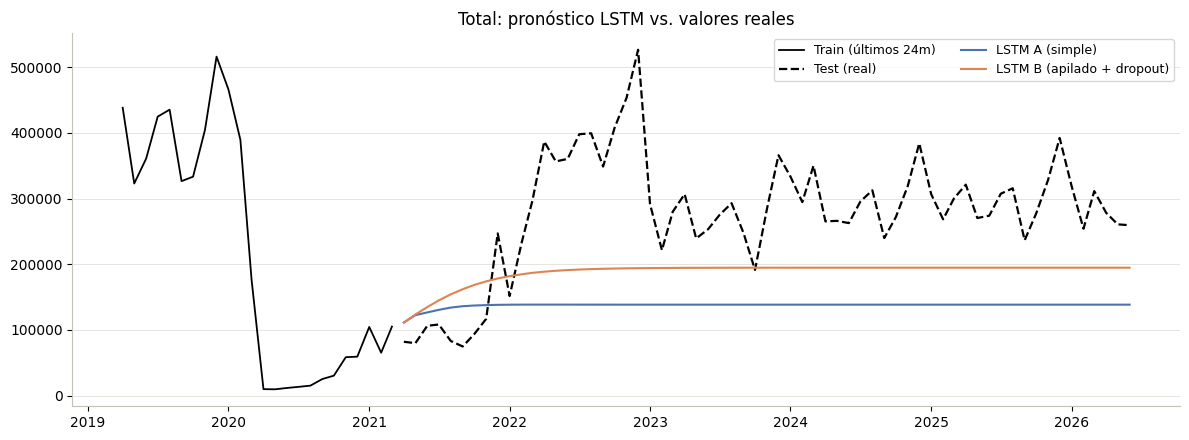

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.5))
s_tr, s_te = series_train['Total'], series_test['Total']
ax.plot(s_tr.index[-24:], s_tr.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(s_te.index, s_te.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(s_te.index, pred_A_total, color=COLORS[0], label='LSTM A (simple)')
ax.plot(s_te.index, pred_B_total, color=COLORS[1], label='LSTM B (apilado + dropout)')
ax.set_title('Total: pronóstico LSTM vs. valores reales')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

## 5. Serie: Aérea

### 5.1 Tuneo del Modelo A (LSTM simple)

In [14]:
info_aerea = prepare_series(series_train['Aérea'])

tabla_A_aerea = grid_search(info_aerea, build_model_A, grid_A)
tabla_A_aerea

,look_back,units,MAE,RMSE
0,12,32,63189.477167,71163.937725
1,12,64,63234.958208,71288.159328
2,6,64,65285.010154,73768.175812
3,6,32,66483.638241,75384.227335


In [15]:
best_A_aerea = tabla_A_aerea.iloc[0].to_dict()
print('mejor configuración Modelo A (Aérea):', best_A_aerea)

modelo_A_aerea, pred_A_aerea = entrenar_final(
    info_aerea, build_model_A, best_A_aerea, steps=len(series_test['Aérea'])
)
metrics_A_aerea = evaluar(series_test['Aérea'].values, pred_A_aerea)
metrics_A_aerea

mejor configuración Modelo A (Aérea): {'look_back': 12.0, 'units': 32.0, 'MAE': 63189.477166518685, 'RMSE': 71163.9377253368}


{'MAE': 64900.33292023743, 'RMSE': 72053.55757737438}

### 5.2 Tuneo del Modelo B (LSTM apilado con dropout)

In [16]:
tabla_B_aerea = grid_search(info_aerea, build_model_B, grid_B)
tabla_B_aerea

,look_back,units,dropout,MAE,RMSE
0,12,64,0.1,56421.870063,61432.487163
1,12,64,0.3,61426.920002,67198.454591
2,12,128,0.3,62596.363045,69094.224874
3,6,128,0.1,62738.448961,69769.955885
4,6,64,0.3,65049.245343,72733.989607
5,6,128,0.3,67221.599692,75738.263291
6,6,64,0.1,67191.299063,76166.685954
7,12,128,0.1,68649.079254,78390.170392


In [17]:
best_B_aerea = tabla_B_aerea.iloc[0].to_dict()
print('mejor configuración Modelo B (Aérea):', best_B_aerea)

modelo_B_aerea, pred_B_aerea = entrenar_final(
    info_aerea, build_model_B, best_B_aerea, steps=len(series_test['Aérea'])
)
metrics_B_aerea = evaluar(series_test['Aérea'].values, pred_B_aerea)
metrics_B_aerea

mejor configuración Modelo B (Aérea): {'look_back': 12.0, 'units': 64.0, 'dropout': 0.1, 'MAE': 56421.87006347815, 'RMSE': 61432.48716310815}


{'MAE': 20843.842740624237, 'RMSE': 28873.685999072783}

### 5.3 Comparación A vs. B para Aérea

In [18]:
comp_aerea = pd.DataFrame([
    dict(modelo='LSTM A (simple)', **hiperparams(best_A_aerea), **metrics_A_aerea),
    dict(modelo='LSTM B (apilado + dropout)', **hiperparams(best_B_aerea), **metrics_B_aerea),
]).set_index('modelo').round(2)
comp_aerea

,look_back,units,MAE,RMSE,dropout
modelo,,,,,
LSTM A (simple),12.0,32.0,64900.33,72053.56,NaN
LSTM B (apilado + dropout),12.0,64.0,20843.84,28873.69,0.1


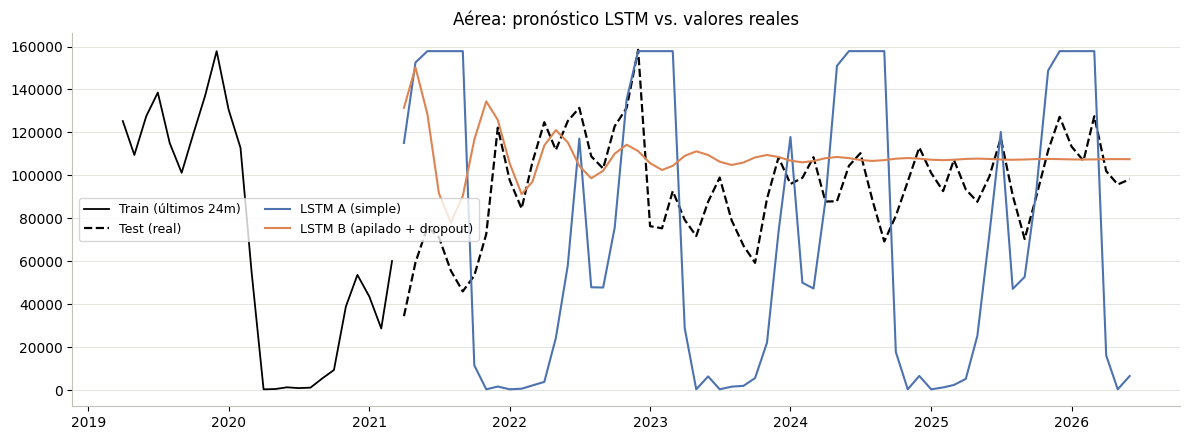

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.5))
s_tr, s_te = series_train['Aérea'], series_test['Aérea']
ax.plot(s_tr.index[-24:], s_tr.values[-24:], color='black', linewidth=1.3, label='Train (últimos 24m)')
ax.plot(s_te.index, s_te.values, color='black', linewidth=1.6, linestyle='--', label='Test (real)')
ax.plot(s_te.index, pred_A_aerea, color=COLORS[0], label='LSTM A (simple)')
ax.plot(s_te.index, pred_B_aerea, color=COLORS[1], label='LSTM B (apilado + dropout)')
ax.set_title('Aérea: pronóstico LSTM vs. valores reales')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

Quedan armadas las 4 tablas de tuneo (tabla_A_total, tabla_B_total, tabla_A_aerea, tabla_B_aerea), las predicciones sobre test de cada modelo (pred_A_total, pred_B_total, pred_A_aerea, pred_B_aerea) y las comparaciones comp_total/comp_aerea. Con esto se puede elegir el mejor LSTM de cada serie y compararlo contra el mejor modelo del Laboratorio 1 (Prophet para Total, Holt-Winters para Aérea).